### Neural Networks

In [103]:
import pandas as pd
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

rng = np.random.default_rng(42)

In [104]:
train_file_path = "../../input/house-prices-advanced-regression-techniques/train.csv"
dataset_df = pd.read_csv(train_file_path)
dataset_df = dataset_df.drop('Id', axis=1)
num_df_idx = dataset_df.select_dtypes(include=['float64', 'int64']).columns
cat_df_idx = dataset_df.select_dtypes(exclude=['float64', 'int64']).columns

In [105]:
# numerical features (exclude SalePrice from standardization)
feature_num_idx = num_df_idx.drop('SalePrice')
data_mean = dataset_df[feature_num_idx].mean()
data_std = dataset_df[feature_num_idx].std()
dataset_df[feature_num_idx] = (dataset_df[feature_num_idx] - data_mean) / data_std
dataset_df[feature_num_idx] = dataset_df[feature_num_idx].fillna(0)
# catagorical features
dataset_df = pd.get_dummies(dataset_df, dummy_na=True)
print(dataset_df.shape)

(1460, 331)


In [106]:
class MyDataset(Dataset):
    def __init__(self, dataset):
        self.X = dataset[:, :-1]
        self.y = dataset[:, -1:]

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [107]:
dataset = torch.tensor(dataset_df.astype('float32').to_numpy(), dtype=torch.float32)
dataset.shape

torch.Size([1460, 331])

In [108]:
in_features = dataset.shape[1] - 1
net = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Linear(256, 1), 
)
loss = nn.MSELoss()

In [109]:
def train(net, dataset, dataset_vali, epochs, lr, weight_decay, batch_size):
    """
    net: nn.Sequential
    dataset: torch.Tensor
    dataset_vali: torch.Tensor
    epochs: int, num of epoch
    lr: float
    weight_decay: float
    batch_size: int
    """
    batch_dataset = MyDataset(dataset)
    batch_dataset_vali = MyDataset(dataset_vali)
    dataloader = DataLoader(batch_dataset, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(params=net.parameters(), lr=lr, weight_decay=weight_decay)
    
    train_loss = []
    vali_loss = []
    
    for _ in range(epochs):
        for X, y in dataloader:
            y = torch.log1p(y)
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
        with torch.no_grad():
            X = dataset[:, :-1]
            y = torch.log1p(dataset[:, -1:])
            X_vali = dataset_vali[:, :-1]
            y_vali = torch.log1p(dataset_vali[:, -1:])
            train_loss.append(loss(net(X), y).item())
            vali_loss.append(loss(net(X_vali), y_vali).item())

    return train_loss, vali_loss

In [110]:
def split_dataset(dataset, vali_ratio=0.25):
    vali_indices = rng.random(len(dataset)) < vali_ratio
    return dataset[~vali_indices], dataset[vali_indices]
data_train, data_vali = split_dataset(dataset)

In [111]:
epochs, lr, weight_decay, batch_size = 100, 1e-3, 0, 64
train_loss, vali_loss = train(net, data_train, data_vali, epochs, lr, weight_decay, batch_size)
print(train_loss, vali_loss)

[1349.6060791015625, 653.2695922851562, 15226.052734375, 3527.65771484375, 450.0873718261719, 15.55217170715332, 28.5794620513916, 5.727114677429199, 0.8292437195777893, 0.12224012613296509, 0.04841312766075134, 0.048405393958091736, 0.04802766814827919, 0.05639299750328064, 0.04692105948925018, 0.04676271602511406, 0.05467653647065163, 0.04571019858121872, 0.04538211598992348, 0.047559794038534164, 0.06325478106737137, 0.05662823095917702, 0.07013183832168579, 0.06634151935577393, 0.051323533058166504, 0.04544808343052864, 0.04710928723216057, 0.042315881699323654, 0.06613670289516449, 0.04406851902604103, 0.05026185140013695, 0.044591229408979416, 0.062138739973306656, 0.042509034276008606, 0.044118884950876236, 0.039494507014751434, 0.038815394043922424, 0.043009813874959946, 0.03936823457479477, 0.04396125301718712, 0.03885674849152565, 0.03940114751458168, 0.0373438261449337, 0.03640975430607796, 0.03560130298137665, 0.037393905222415924, 0.03705398738384247, 0.04796022176742554, 

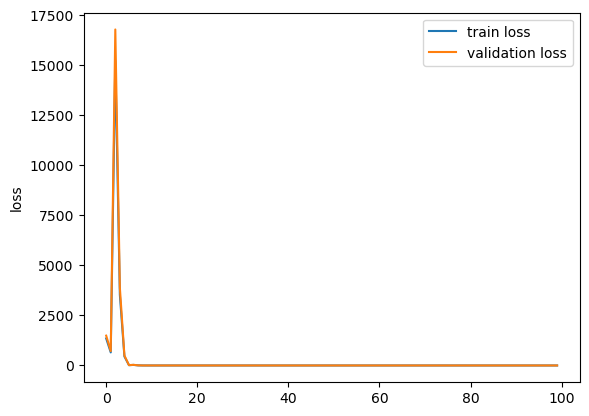

In [112]:
fig, ax = plt.subplots()
x = list(range(len(train_loss)))
ax.plot(x, train_loss, label='train loss')
ax.plot(x, vali_loss, label='validation loss')
ax.set_ylabel('loss')
ax.legend()

In [113]:
vali_loss[-1]

0.017115669324994087